<div style="text-align: center;">
    <a href="https://www.hi-paris.fr/">
        <img border="0" src="https://www.hi-paris.fr/wp-content/uploads/2020/09/logo-hi-paris-retina.png" width="25%"></a>
    <a href="https://www.dataia.eu/">
        <img border="0" src="https://github.com/ramp-kits/template-kit/raw/main/img/DATAIA-h.png" width="70%"></a>
</div>

# FLIP AAV Capsid Optimization Challenge

*Predicting protein fitness from amino acid sequences*

<i> Cécile Luc </i><br/>
<i> Alizée Mesnard </i><br/>
<i> Hamza Boukhriss </i><br/>
<i> Laurian Truong </i><br/>
<i> Nicolas Bieszczad </i><br/>
<i> Nardi Xhepi </i><br/>

## Introduction



### Where does the data come from?

The data comes from the [**FLIP** (Fitness Landscape Inference for Proteins) benchmark](https://datasets-benchmarks-proceedings.neurips.cc/paper/2021/file/2b44928ae11fb9384c4cf38708677c48-Paper-round2.pdf), specifically the **AAV** (Adeno-Associated Virus) dataset. It was generated through a deep mutational scanning (DMS) experiment that measured the packaging fitness of ~280,000 variants of the AAV2 capsid protein VP1. 

Each variant is a mutated version of the wild-type AAV2 VP1 protein (~735 amino acids long), and its fitness score reflects how well the capsid packages viral DNA — a critical function for gene therapy delivery.

### What is the task?

Given an amino acid sequence of an AAV capsid variant, **predict its fitness score** (a continuous value). This is a **regression** task evaluated using **Spearman's rank correlation coefficient (ρ)**.

The key challenge is **epistasis** (non-additive mutation interactions): the model is trained on variants with **1–2 mutations** but must generalize to variants with **3 or more mutations**. This means simple additive models will fail — the model must learn how mutations interact.

### Why does it matter?

AAV vectors are the leading platform for **gene therapy** — they deliver therapeutic genes into patients' cells. Engineering better capsids is crucial for:
- **Improving tissue targeting** (e.g., reaching the brain, liver, or muscles)
- **Evading immune responses** that reduce treatment efficacy
- **Increasing packaging efficiency** for larger therapeutic genes

Being able to predict the fitness of unseen multi-mutant capsids would dramatically accelerate the design of next-generation gene therapy vectors, reducing the need for expensive wet-lab experiments.

## Exploratory Data Analysis

Let's explore the dataset to understand its structure and key properties.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

# Load the training data
from ingestion_program.ingestion import get_train_data
X_train, y_train = get_train_data("dev_phase/input_data")

print(f"Training set: {X_train.shape[0]} samples")
print(f"Features: {X_train.columns.tolist()}")
print(f"Target: {y_train.columns.tolist()}")
X_train.head(3)

Training set: 31807 samples
Features: ['sequence']
Target: ['target']


,sequence
0,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...
1,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...
2,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...


### Data overview

Each sample is a protein sequence (a string of ~735 amino acid characters) with an associated fitness score.

In [2]:
# Basic statistics on the sequences
seq_lengths = X_train['sequence'].str.len()
print(f"Sequence length — Min: {seq_lengths.min()}, Max: {seq_lengths.max()}, Mean: {seq_lengths.mean():.1f}")
print(f"\nSequence length distribution:")
print(seq_lengths.value_counts().sort_index())

print(f"\nTarget (fitness) statistics:")
print(y_train['target'].describe())

Sequence length — Min: 734, Max: 737, Mean: 735.9

Sequence length distribution:
sequence
734       28
735    10462
736    14856
737     6461
Name: count, dtype: int64

Target (fitness) statistics:
count    31807.000000
mean        -3.354641
std          3.028819
min        -10.217098
25%         -5.597328
50%         -4.441116
75%         -1.312714
max          9.536457
Name: target, dtype: float64


### Fitness distribution

The fitness score is a continuous value. Negative values indicate poor packaging ability, while positive values indicate functional capsids. The wild-type (unmutated) protein has the highest fitness (~9.5).

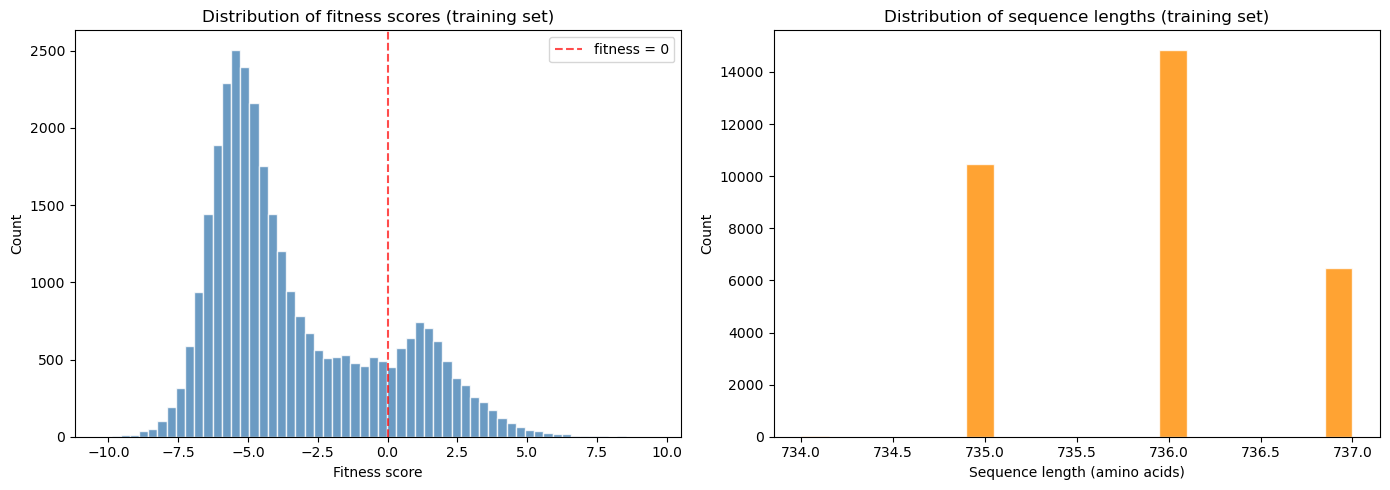

Fraction of functional variants (fitness > 0): 18.9%
Fraction of non-functional variants (fitness < -5): 39.1%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitness distribution
axes[0].hist(y_train['target'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='fitness = 0')
axes[0].set_xlabel('Fitness score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of fitness scores (training set)')
axes[0].legend()

# Sequence length distribution
axes[1].hist(seq_lengths, bins=20, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Sequence length (amino acids)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of sequence lengths (training set)')

plt.tight_layout()
plt.show()

print(f"Fraction of functional variants (fitness > 0): {(y_train['target'] > 0).mean():.1%}")
print(f"Fraction of non-functional variants (fitness < -5): {(y_train['target'] < -5).mean():.1%}")

### The epistasis challenge: train on few mutations, test on many



The key difficulty of this challenge is **distribution shift**. The training set contains variants with **1–2 mutations** relative to the wild-type, while the test set contains variants with **3 or more mutations**.

This means the model must learn to generalize from simple mutations to complex combinatorial ones — a phenomenon called **epistasis**, where the effect of combining mutations is not simply the sum of individual effects.

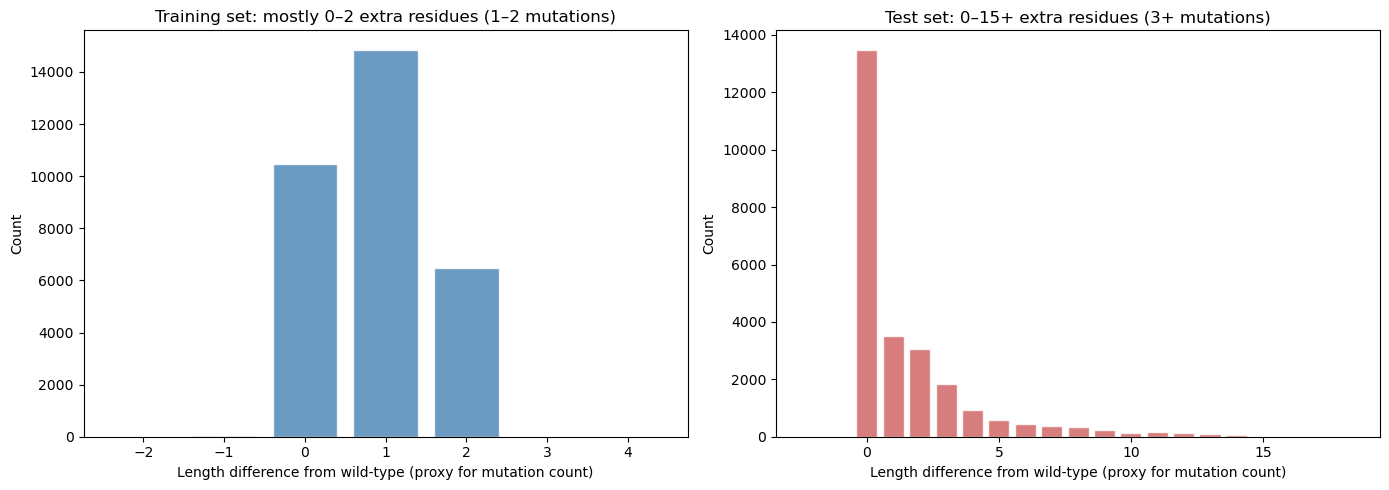

This is the core challenge: the test distribution is very different from training!


In [4]:
# Visualize mutation counts via sequence length difference from wild-type (735 aa)
WT_LENGTH = 735

train_mutations = seq_lengths - WT_LENGTH
test_features = pd.read_csv("dev_phase/input_data/test/test_features.csv")
test_mutations = test_features['sequence'].str.len() - WT_LENGTH

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_mutations, bins=range(-2, 6), color='steelblue', edgecolor='white',
             alpha=0.8, align='left', rwidth=0.8)
axes[0].set_xlabel('Length difference from wild-type (proxy for mutation count)')
axes[0].set_ylabel('Count')
axes[0].set_title('Training set: mostly 0–2 extra residues (1–2 mutations)')

axes[1].hist(test_mutations, bins=range(-2, 20), color='indianred', edgecolor='white',
             alpha=0.8, align='left', rwidth=0.8)
axes[1].set_xlabel('Length difference from wild-type (proxy for mutation count)')
axes[1].set_ylabel('Count')
axes[1].set_title('Test set: 0–15+ extra residues (3+ mutations)')

plt.tight_layout()
plt.show()

print("This is the core challenge: the test distribution is very different from training!")

### Amino acid composition

AAV capsid sequences are composed of the 20 standard amino acids. Let's look at the average amino acid composition across training sequences.

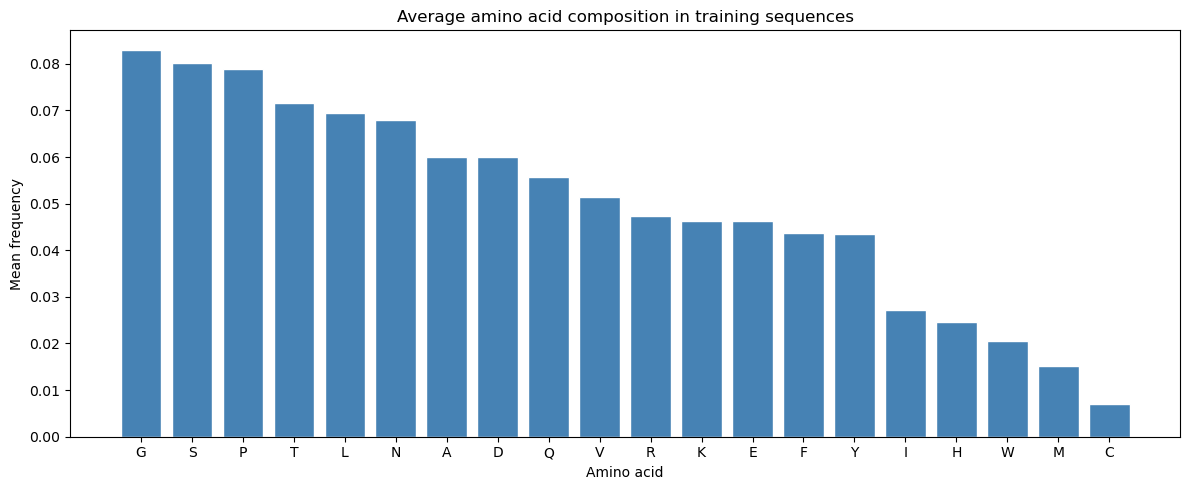

Most frequent amino acids:  G, S, P, T, L
Least frequent amino acids: I, H, W, M, C


In [5]:
from collections import Counter

AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY'

# Compute average amino acid frequency across training sequences
aa_freqs = []
for seq in X_train['sequence'].values[:5000]:  # sample for speed
    counts = Counter(seq)
    total = len(seq)
    aa_freqs.append({aa: counts.get(aa, 0) / total for aa in AMINO_ACIDS})

aa_df = pd.DataFrame(aa_freqs)
mean_freqs = aa_df.mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(mean_freqs.index, mean_freqs.values, color='steelblue', edgecolor='white')
plt.xlabel('Amino acid')
plt.ylabel('Mean frequency')
plt.title('Average amino acid composition in training sequences')
plt.tight_layout()
plt.show()

print("Most frequent amino acids: ", ', '.join(mean_freqs.head(5).index))
print("Least frequent amino acids:", ', '.join(mean_freqs.tail(5).index))

## Exploring Additional Biophysical Features

As indicated in the `README.md`, we propose four additional biophysical features that represent the chemical and physical properties of the amino acids. A raw sequence contains hidden structural information that standard letter counting cannot capture. 

By extracting these features, you can compute the **net charge**, which influences cellular interactions, and the **average hydrophobicity**, which drives protein folding. You will also calculate the **hydrophobic moment**, a proxy for amphipathicity showing if the sequence has distinct faces, and an **instability index** that estimates how quickly the protein might degrade in a cell. Let's extract these features and visualize their relationship with the fitness score.

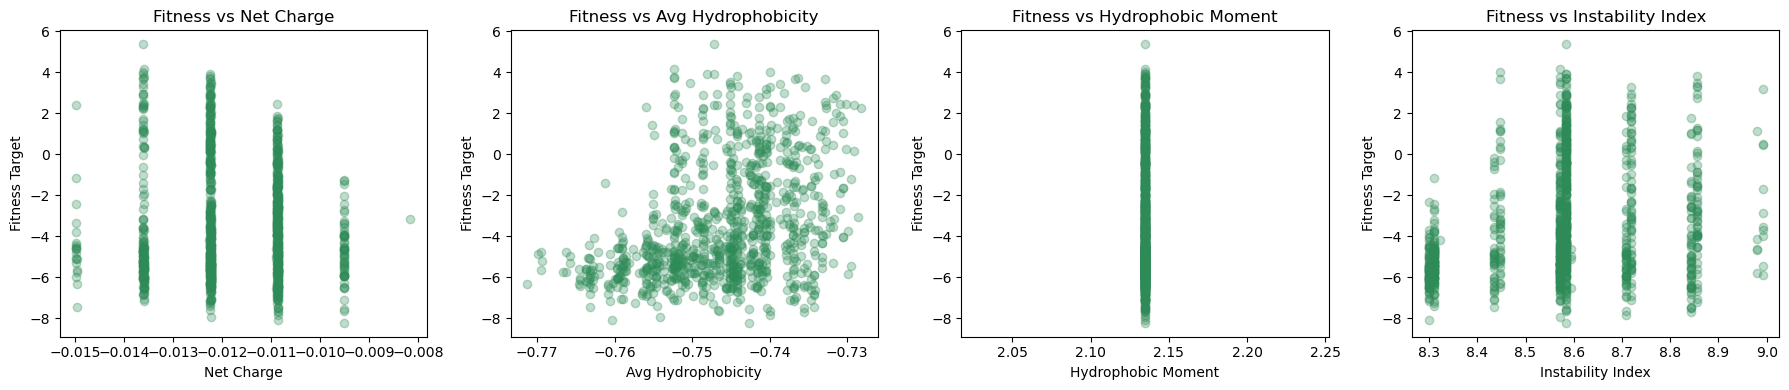

In [6]:
def extract_bio_features_for_eda(sequence):
    """Extract biologically-relevant physicochemical features."""
    CHARGED = {'K': 1, 'R': 1, 'D': -1, 'E': -1}
    KYTE_DOOLITTLE = {
        'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
        'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
        'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
        'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
    }

    net_charge = sum(CHARGED.get(aa, 0) for aa in sequence)
    normalized_charge = net_charge / len(sequence)
    avg_hydrophobicity = np.mean([KYTE_DOOLITTLE.get(aa, 0) for aa in sequence])

    window_size = 11
    angle = 100
    moments = []
    for i in range(len(sequence) - window_size + 1):
        window = sequence[i:i+window_size]
        sin_sum = sum(KYTE_DOOLITTLE.get(aa, 0) * np.sin(np.radians(angle * j)) for j, aa in enumerate(window))
        cos_sum = sum(KYTE_DOOLITTLE.get(aa, 0) * np.cos(np.radians(angle * j)) for j, aa in enumerate(window))
        moments.append(np.sqrt(sin_sum**2 + cos_sum**2) / window_size)
    hydrophobic_moment = max(moments) if moments else 0.0

    instability_proxy = sum(1 for i in range(len(sequence) - 1)
                            if ((KYTE_DOOLITTLE.get(sequence[i], 0) > 2.0 and sequence[i+1] in CHARGED) or
                                (sequence[i] in CHARGED and KYTE_DOOLITTLE.get(sequence[i+1], 0) > 2.0)))
    instability_index = (instability_proxy / (len(sequence) - 1)) * 100

    return [normalized_charge, avg_hydrophobicity, hydrophobic_moment, instability_index]

# Compute features on a subset to visualize
sample_df = X_train.head(1000).copy()
bio_features = np.array([extract_bio_features_for_eda(seq) for seq in sample_df['sequence']])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
feature_names = ['Net Charge', 'Avg Hydrophobicity', 'Hydrophobic Moment', 'Instability Index']
for i in range(4):
    axes[i].scatter(bio_features[:, i], y_train['target'].head(1000), alpha=0.3, color='seagreen')
    axes[i].set_xlabel(feature_names[i])
    axes[i].set_ylabel('Fitness Target')
    axes[i].set_title(f'Fitness vs {feature_names[i]}')
plt.tight_layout()
plt.show()

### What do these plots tell us?

At first glance, these plots might look strange, but they reveal crucial insights about our dataset:

1. **Discrete vertical lines (Net Charge, Instability Index):** Remember that our training sequences are ~735 amino acids long, but they only differ from the wild-type by **1 or 2 mutations**. Changing a single amino acid only shifts global properties by discrete, tiny amounts.
2. **Zero variance (Hydrophobic Moment):** The hydrophobic moment forms a single vertical line. This means it has virtually zero variance across this specific dataset! **Lesson learned:** Always do EDA. Feeding a zero-variance feature into a machine learning model is useless.

3. **Weak linear correlation:** None of these features perfectly predict the fitness on their own. This highlights why predicting protein fitness is hard and requires combining multiple features (like k-mers + biophysical traits) or using non-linear models to capture complex interactions."

So since our training sequences only have 1 or 2 mutations, the global changes in these features are extremely small.
Now, let's use **Binning**. We will divide our sequences into two extreme categories: **Functional** (fitness > 0) and **Dead** (fitness < -5). By plotting their distributions using boxplots, we can observe statistical differences. For example, do dead viruses tend to be more unstable? Let's find out!"

Extraction des features en cours...
Extraction terminée !


C:\Users\Cecil\AppData\Local\Temp\ipykernel_22008\1026613770.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y=feature, data=filtered_df, ax=axes[i], palette=palette, width=0.4)
C:\Users\Cecil\AppData\Local\Temp\ipykernel_22008\1026613770.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y=feature, data=filtered_df, ax=axes[i], palette=palette, width=0.4)
C:\Users\Cecil\AppData\Local\Temp\ipykernel_22008\1026613770.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y=feature, data=filtered_

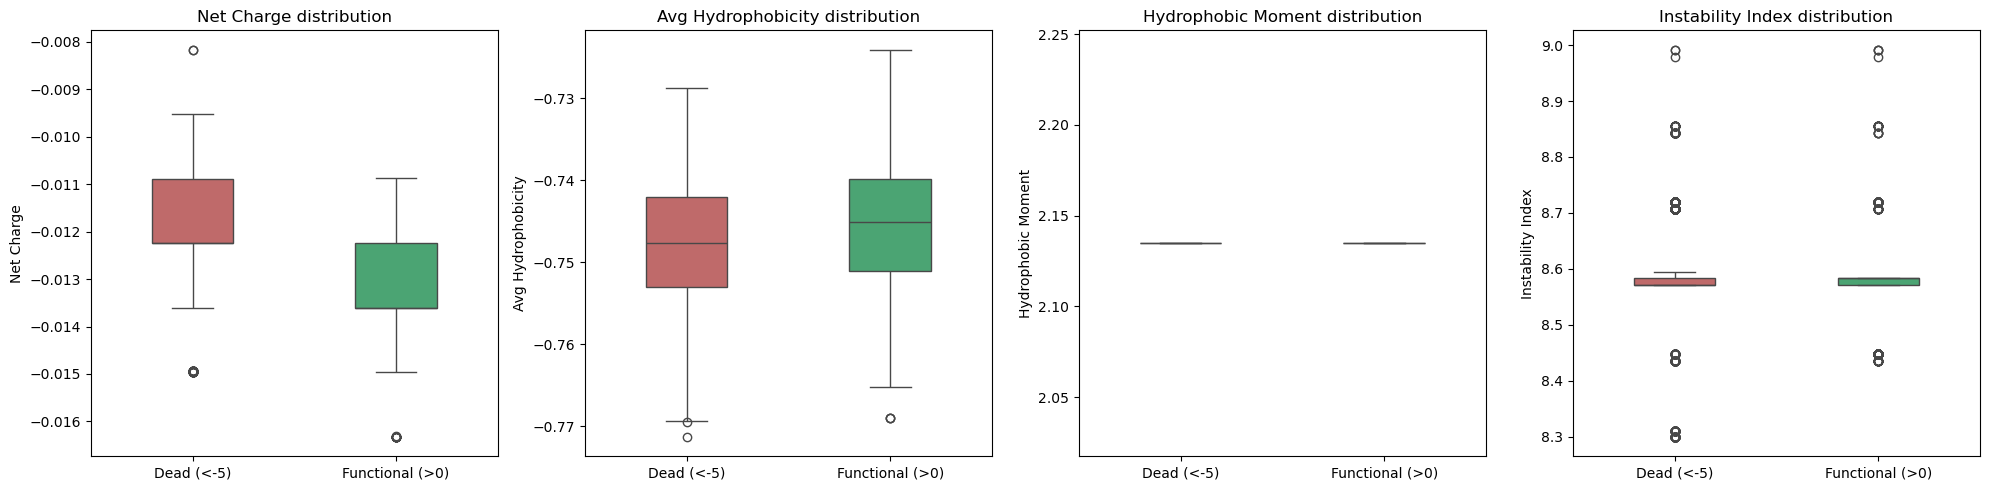

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_bio_features_for_eda(sequence):
    """Extract biologically-relevant physicochemical features (OPTIMIZED)."""
    CHARGED = {'K': 1, 'R': 1, 'D': -1, 'E': -1}
    KYTE_DOOLITTLE = {
        'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
        'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
        'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
        'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
    }

    seq_len = len(sequence)
    net_charge = sum(CHARGED.get(aa, 0) for aa in sequence) / seq_len
    h_vals = np.array([KYTE_DOOLITTLE.get(aa, 0) for aa in sequence])
    avg_hydrophobicity = np.mean(h_vals)

    window_size = 11
    angles = np.radians(100 * np.arange(window_size))
    sin_vals = np.sin(angles)
    cos_vals = np.cos(angles)
    
    moments = []
    for i in range(seq_len - window_size + 1):
        window_h = h_vals[i:i+window_size]
        sin_sum = np.dot(window_h, sin_vals)
        cos_sum = np.dot(window_h, cos_vals)
        moments.append(np.sqrt(sin_sum**2 + cos_sum**2) / window_size)
    hydrophobic_moment = max(moments) if moments else 0.0

    instability_proxy = 0
    for i in range(seq_len - 1):
        aa1, aa2 = sequence[i], sequence[i+1]
        h1, h2 = h_vals[i], h_vals[i+1]
        if (h1 > 2.0 and aa2 in CHARGED) or (aa1 in CHARGED and h2 > 2.0):
            instability_proxy += 1
    instability_index = (instability_proxy / (seq_len - 1)) * 100

    return [net_charge, avg_hydrophobicity, hydrophobic_moment, instability_index]

# 1. Extract features for a representative sample (5000 sequences)
print("Extraction des features en cours...")
sample_df = X_train.head(5000).copy()
sample_targets = y_train['target'].head(5000)
bio_features = np.array([extract_bio_features_for_eda(seq) for seq in sample_df['sequence']])
print("Extraction terminée !")

plot_df = pd.DataFrame(bio_features, columns=['Net Charge', 'Avg Hydrophobicity', 'Hydrophobic Moment', 'Instability Index'])
plot_df['Fitness'] = sample_targets.values

# 3. Categorize variants into "Functional" vs "Dead"
def categorize_fitness(score):
    if score > 0:
        return 'Functional (>0)'
    elif score < -5:
        return 'Dead (<-5)'
    return 'Intermediate'

plot_df['Category'] = plot_df['Fitness'].apply(categorize_fitness)
filtered_df = plot_df[plot_df['Category'].isin(['Functional (>0)', 'Dead (<-5)'])]

# 4. Plot Boxplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
feature_names = ['Net Charge', 'Avg Hydrophobicity', 'Hydrophobic Moment', 'Instability Index']
palette = {'Functional (>0)': 'mediumseagreen', 'Dead (<-5)': 'indianred'}

for i, feature in enumerate(feature_names):
    sns.boxplot(x='Category', y=feature, data=filtered_df, ax=axes[i], palette=palette, width=0.4)
    axes[i].set_title(f'{feature} distribution')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

### Analysis of the Biophysical Features

By grouping the sequences into "Functional" and "Dead" categories, the boxplots reveal interesting biological patterns that a machine learning model can learn from:

**Net Charge distribution**
The plot shows that functional viruses tend to have a slightly more negative net charge compared to the dead ones. This suggests that maintaining a specific electrical balance is important for the capsid to assemble correctly and interact with its environment.

**Average Hydrophobicity distribution**
We can observe that functional variants are slightly more hydrophobic on average than the non-functional ones. Since hydrophobicity drives how a protein folds in water, a proper hydrophobic balance is likely crucial for the protein to maintain its stable 3D structure.

**Hydrophobic Moment distribution**
Both boxes are completely flat and look like a single horizontal line. This happens because changing just one or two amino acids does not alter the global maximum hydrophobic moment of such a long sequence. This is a great reminder that some features have zero variance and will not help the model learn anything useful.

**Instability Index distribution**
The median instability score is almost identical for both functional and dead viruses. However, the dead category contains many more extreme outliers. This indicates that while the average instability doesn't change much, certain specific mutations completely break the protein and result in abnormal instability scores.

## Challenge Evaluation

### Metric 1: Spearman's Rank Correlation (ρ)

We use **Spearman's rank correlation** to evaluate predictions. In protein engineering, **ranking variants correctly matters more than predicting exact fitness values**. A researcher wants to know *which* variants are the best, not necessarily by how much.

$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

where $d_i$ is the difference in ranks between predicted and true fitness for variant $i$.

| Score | Interpretation |
|-------|----------------|
| ρ = 1.0 | Perfect ranking |
| ρ ≥ 0.5 | Good correlation |
| ρ = 0.0 | Random ranking |
| ρ < 0.0 | Anti-correlated |

### Metric 2: Precision@100

As indicated in the `README.md`, we have introduced an additional metric called **Precision@100**. While the Spearman correlation provides an excellent measure of the overall ranking of variants across the entire spectrum, it does not perfectly reflect the reality of a biology laboratory. 

In practice, researchers cannot synthesize and evaluate tens of thousands of proteins; they can only test a highly restricted batch, such as the top 100 candidates. Precision@100 calculates the exact proportion of the actual true top 100 variants that your model successfully identified and placed in its own predicted top 100. This metric is therefore crucial to demonstrate the practical and experimental relevance of your predictions.

In [7]:
def compute_top_k_precision(predictions, targets, k=100):
    """Compute Precision@k: fraction of true top-k variants in predicted top-k."""
    y_pred = np.array(predictions).flatten()
    y_true = np.array(targets).flatten()

    mask = ~(pd.isna(y_pred) | pd.isna(y_true))
    y_pred = y_pred[mask]
    y_true = y_true[mask]

    if len(y_pred) < k:
        k = len(y_pred)

    top_k_pred_indices = set(np.argsort(y_pred)[-k:])
    top_k_true_indices = set(np.argsort(y_true)[-k:])

    overlap = len(top_k_pred_indices & top_k_true_indices)
    return float(overlap / k)

### Evaluation strategy

The test data is split into two sets:
- **Public test** (50%): Spearman correlation is shown on the leaderboard during the competition.
- **Private test** (50%): Used for the final ranking, revealed only at the end.

Both test sets contain variants with **3+ mutations** (not seen during training), so the model must generalize beyond simple single/double mutants.

### Data split summary

| Split | Samples | Mutations | Purpose |
|-------|---------|-----------|---------|
| Train | 31,807 | 1–2 | Model training |
| Public test | 25,388 | 3+ | Leaderboard score |
| Private test | 25,388 | 3+ | Final ranking |

## Submission Format

Participants must submit a Python file named `submission.py` containing a `get_model()` function that returns a scikit-learn compatible model.

### Requirements

Your model must implement:
- **`fit(X, y)`**: Train on a DataFrame `X` with a `sequence` column and a target `y` (fitness scores).
- **`predict(X)`**: Return predicted fitness scores for new sequences.

### Example structure

```python
from sklearn.base import BaseEstimator, RegressorMixin

class MyModel(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        # X is a DataFrame with a 'sequence' column
        # y contains the fitness scores
        ...
        return self
    
    def predict(self, X):
        # Return predicted fitness scores
        ...
        return predictions

def get_model():
    return MyModel()
```

## Baseline Solution

Below is the baseline submission. It extracts features from protein sequences (amino acid composition + k-mer frequencies) and uses Ridge regression for prediction. Notice that the method `_get_bio_features` is present but **currently unused** in the final feature array `_sequence_to_features`. Can you activate it to boost the score?

In [8]:
# %load solution/submission.py
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import numpy as np
from collections import Counter

# Standard amino acids
AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY'
AA_TO_IDX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

class SequenceFitnessRegressor(BaseEstimator, RegressorMixin):
    """
    Fitness prediction model using multiple sequence features:
    - Amino acid composition (frequency of each amino acid)
    - K-mer frequencies (2-mers and 3-mers)
    - Sequence length
    
    Uses Ridge regression for robust high-dimensional fitting.
    """
    
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.model = Ridge(alpha=alpha)
        self.scaler = StandardScaler()
        self.kmer2_vocab = None
        self.kmer3_vocab = None
    
    def _get_aa_composition(self, sequence):
        """Get amino acid composition (frequency of each AA)."""
        counts = Counter(sequence)
        total = len(sequence)
        return np.array([counts.get(aa, 0) / total for aa in AMINO_ACIDS])
    
    def _get_kmer_counts(self, sequence, k, vocab):
        """Get k-mer frequency vector."""
        kmers = [sequence[i:i+k] for i in range(len(sequence) - k + 1)]
        counts = Counter(kmers)
        total = len(kmers) if kmers else 1
        return np.array([counts.get(kmer, 0) / total for kmer in vocab])
    
    def _build_kmer_vocab(self, sequences, k):
        """Build vocabulary of k-mers from sequences."""
        all_kmers = set()
        for seq in sequences:
            for i in range(len(seq) - k + 1):
                all_kmers.add(seq[i:i+k])
        return sorted(all_kmers)

    def _get_bio_features(self, sequence):
        """Extract biologically-relevant physicochemical features."""
        CHARGED = {'K': 1, 'R': 1, 'D': -1, 'E': -1}
        KYTE_DOOLITTLE = {
            'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
            'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
            'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
            'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
        }

        net_charge = sum(CHARGED.get(aa, 0) for aa in sequence)
        normalized_charge = net_charge / len(sequence)

        avg_hydrophobicity = np.mean([KYTE_DOOLITTLE.get(aa, 0) for aa in sequence])

        window_size = 11
        angle = 100
        moments = []
        for i in range(len(sequence) - window_size + 1):
            window = sequence[i:i+window_size]
            sin_sum = sum(KYTE_DOOLITTLE.get(aa, 0) * np.sin(np.radians(angle * j))
                          for j, aa in enumerate(window))
            cos_sum = sum(KYTE_DOOLITTLE.get(aa, 0) * np.cos(np.radians(angle * j))
                          for j, aa in enumerate(window))
            moment = np.sqrt(sin_sum**2 + cos_sum**2) / window_size
            moments.append(moment)
        hydrophobic_moment = max(moments) if moments else 0.0

        instability_proxy = 0
        for i in range(len(sequence) - 1):
            aa1, aa2 = sequence[i], sequence[i+1]
            if (KYTE_DOOLITTLE.get(aa1, 0) > 2.0 and aa2 in CHARGED) or \
               (aa1 in CHARGED and KYTE_DOOLITTLE.get(aa2, 0) > 2.0):
                instability_proxy += 1
        instability_index = (instability_proxy / (len(sequence) - 1)) * 100

        return [normalized_charge, avg_hydrophobicity, hydrophobic_moment, instability_index]

    def _sequence_to_features(self, sequence):
        """Convert sequence to feature vector."""
        features = []
        
        # Amino acid composition (20 features)
        features.extend(self._get_aa_composition(sequence))
        
        # 2-mer frequencies
        features.extend(self._get_kmer_counts(sequence, 2, self.kmer2_vocab))
        
        # 3-mer frequencies
        features.extend(self._get_kmer_counts(sequence, 3, self.kmer3_vocab))
        
        # Sequence length (normalized)
        features.append(len(sequence) / 735.0)  # Normalize by typical AAV length
        
        return np.array(features)
    
    def fit(self, X, y):
        """Fit the model on sequences and fitness values.
        
        Args:
            X: DataFrame with 'sequence' column
            y: Target values (DataFrame or array-like)
        """
        sequences = X['sequence'].values
        
        # Handle y as DataFrame or array
        import pandas as pd
        if isinstance(y, pd.DataFrame):
            y = y.values.ravel()
        elif hasattr(y, 'values'):
            y = y.values.ravel()
        
        # Build k-mer vocabularies
        print("  Building k-mer vocabularies...")
        self.kmer2_vocab = self._build_kmer_vocab(sequences, 2)
        self.kmer3_vocab = self._build_kmer_vocab(sequences, 3)
        
        print(f"  2-mer vocab size: {len(self.kmer2_vocab)}")
        print(f"  3-mer vocab size: {len(self.kmer3_vocab)}")
        
        # Convert all sequences to features
        print("  Extracting features...")
        X_features = np.array([self._sequence_to_features(seq) for seq in sequences])
        
        print(f"  Total features: {X_features.shape[1]}")
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X_features)
        
        # Fit Ridge regression
        print("  Training Ridge regression...")
        self.model.fit(X_scaled, y)
        
        return self
    
    def predict(self, X):
        """Predict fitness for new sequences."""
        sequences = X['sequence'].values
        X_features = np.array([self._sequence_to_features(seq) for seq in sequences])
        X_scaled = self.scaler.transform(X_features)
        return self.model.predict(X_scaled)

def get_model():
    """Return the model for the FLIP AAV fitness prediction challenge."""
    return SequenceFitnessRegressor(alpha=10.0)

## Local Testing Pipeline

Let's train the baseline model and evaluate it locally to see how it performs across both metrics. This is exactly the pipeline that runs on Codabench when you submit.

In [9]:
from scipy.stats import spearmanr
import time

# 1. Load training data
X_train, y_train = get_train_data("dev_phase/input_data")

# 2. Train the baseline model
model = get_model()
print("Training the baseline model...")
start = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start
print(f"Training completed in {train_time:.1f}s")

# 3. Predict on test set
X_test = pd.read_csv("dev_phase/input_data/test/test_features.csv")
y_test_true = pd.read_csv("dev_phase/reference_data/test_labels.csv")

print("\nPredicting on test set...")
start = time.time()
y_test_pred = model.predict(X_test)
test_time = time.time() - start
print(f"Prediction completed in {test_time:.1f}s")

# 4. Evaluate with Spearman correlation
corr, pval = spearmanr(y_test_pred, y_test_true['target'].values)
print(f"\n{'='*40}")
print(f"Spearman correlation on public test: {corr:.4f}")

# 5. Evaluate with Precision@100
prec_100 = compute_top_k_precision(y_test_pred, y_test_true['target'].values, k=100)
print(f"Precision@100 on public test:        {prec_100:.4f}")
print(f"{'='*40}")

Training the baseline model...
  Building k-mer vocabularies...
  2-mer vocab size: 400
  3-mer vocab size: 4741
  Extracting features...
  Total features: 5162
  Training Ridge regression...
Training completed in 169.5s

Predicting on test set...
Prediction completed in 98.1s

Spearman correlation on public test: 0.4206
Precision@100 on public test:        0.0000


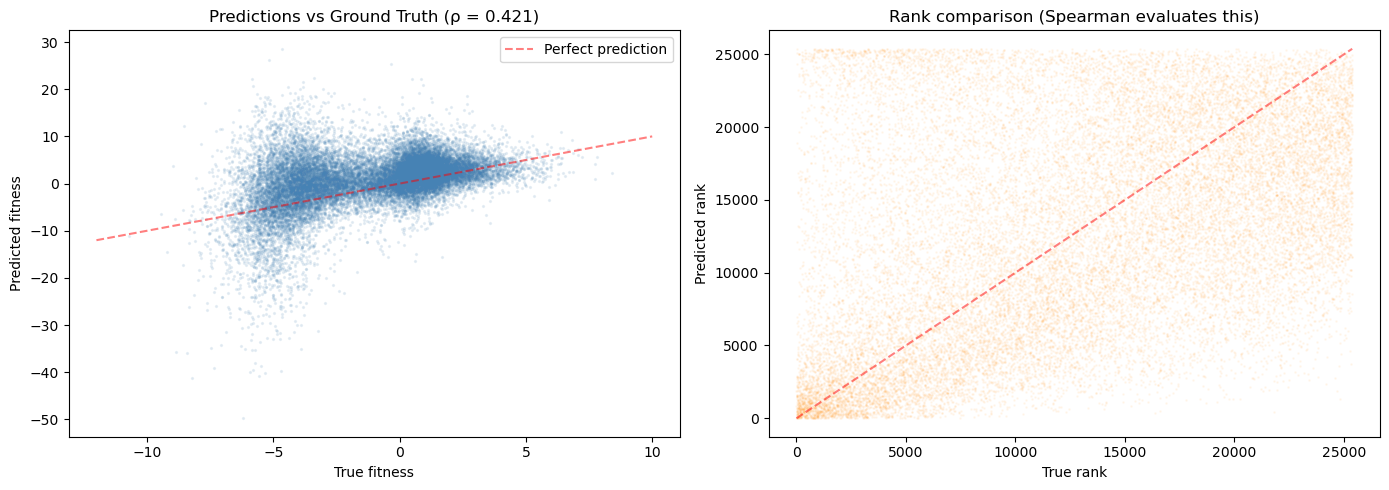

In [10]:
# Visualize predictions vs ground truth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_true['target'].values, y_test_pred, alpha=0.1, s=2, color='steelblue')
axes[0].plot([-12, 10], [-12, 10], 'r--', alpha=0.5, label='Perfect prediction')
axes[0].set_xlabel('True fitness')
axes[0].set_ylabel('Predicted fitness')
axes[0].set_title(f'Predictions vs Ground Truth (ρ = {corr:.3f})')
axes[0].legend()

# Rank comparison
true_ranks = y_test_true['target'].rank().values
pred_ranks = pd.Series(y_test_pred).rank().values
axes[1].scatter(true_ranks, pred_ranks, alpha=0.05, s=1, color='darkorange')
axes[1].plot([0, len(true_ranks)], [0, len(true_ranks)], 'r--', alpha=0.5)
axes[1].set_xlabel('True rank')
axes[1].set_ylabel('Predicted rank')
axes[1].set_title('Rank comparison (Spearman evaluates this)')

plt.tight_layout()
plt.show()

## Submission on Codabench

To submit your solution on the [Codabench platform](https://www.codabench.org/):

1. **Create your `submission.py` file** with a `get_model()` function (see format above).
2. **Zip it**: `zip submission.zip submission.py`
3. **Upload** the zip file on the competition page.

The platform will:
- Run the ingestion program: load your model, train it, and generate predictions
- Run the scoring program: compute Spearman correlation on public and private test sets
- Display your public test score on the leaderboard

### Tips for improvement

- **Feature engineering**: Start by activating the biophysical features provided in the baseline, then try positional encoding or mutation-specific features.
- **Non-linear models**: Gradient boosting (XGBoost, LightGBM) or neural networks may capture epistatic interactions better than linear models.
- **Protein language models**: Pre-trained models like ESM-2 or ProtBERT can provide powerful sequence embeddings.
- **Ensemble methods**: Combining multiple models often improves robustness.

Good luck! 🧬